In [61]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action = 'ignore')

In [62]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [63]:
origin = '/content/drive/MyDrive/새싹과정/my/3주차/데이터/2차 실전 - 이커머스'

#csv 파일을 읽기(파일은 origin 경로의 '~' 파일 경로로 연결합니다)
#os.path.join(폴더 경로, 파일 경로)
customer = pd.read_csv(os.path.join(origin, 'Customer_info.csv'))
discount = pd.read_csv(os.path.join(origin, 'Discount_info.csv'))
marketing = pd.read_csv(os.path.join(origin, 'Marketing_info.csv'))
onlinesales = pd.read_csv(os.path.join(origin, 'Onlinesales_info.csv'))

In [64]:
#컬럼 찍어 정보 확인
print(customer.columns)
print(discount.columns)
print(marketing.columns)
print(onlinesales.columns)

Index(['고객ID', '성별', '고객지역', '가입기간'], dtype='object')
Index(['월', '제품카테고리', '쿠폰코드', '할인율'], dtype='object')
Index(['날짜', '오프라인비용', '온라인비용'], dtype='object')
Index(['고객ID', '거래ID', '거래날짜', '제품ID', '제품카테고리', '수량', '평균금액', '배송료', '쿠폰상태'], dtype='object')


# 1.데이터 만들기

 - merge(데이터프레임을 특정 기준으로 병합)
 - concat(행열 기준으로 병합)

In [65]:
# 1.merge 진행 : 고객 - 세일즈
bigdata = pd.merge(customer, onlinesales)
bigdata.head()

df = bigdata.copy()
df.head()

,고객ID,성별,고객지역,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태
0,USER_1358,남,Chicago,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
1,USER_1358,남,Chicago,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used
2,USER_1358,남,Chicago,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used
3,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used
4,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used


In [66]:
# 2. 고객정보 + 거래내역 + 할인행사 적용(각 거래 내역에)
# '월'별 '제품 카테고리' 기준을 통해 각 거래내역(행) 할인율 덧붙여야함
# '월' 정보가 없으니 datetime 이용해 '월' 추출, 새로운 행 만들기

df['월'] = pd.to_datetime(df['거래날짜']).dt.month
df.head()

#df['월'] 기준으로, 할인율을 각 행에 적용
#합치려는 discount 데이터프레임을 확인해보면 월은 문자로 되어 있음. 숫자로 전환 진행.
discount['월'].replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
                       'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9,
                        'Oct':10, 'Nov':11, 'Dec':12}, inplace=True)

#df['월']과 discount['월'] 모두 '숫자로 된 달' -> 얘네 기준 merge
total_df = pd.merge(df, discount, on=['월','제품카테고리'], how = 'left')
total_df.head()

,고객ID,성별,고객지역,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,쿠폰코드,할인율
0,USER_1358,남,Chicago,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
1,USER_1358,남,Chicago,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0
2,USER_1358,남,Chicago,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,OFF10,10.0
3,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,SALE10,10.0
4,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,AIO10,10.0


In [67]:
tdf = total_df.copy()

# 2.파생변수 만들기


- '시각화' 전제로 어떤 파생변수 만들지 계획 (스켈레톤 코딩)
- 복습 포인트:
    - groupby('기준').agg()
    - dataframe['열이름'] 사칙연산
    - dataframe.loc[행 조건, 열 조건]


In [68]:
#tdf에 있는 '할인율' 결측치 보정
#1. 쿠폰을 안 썼거나, 쿠폰이 매칭되지 않는 빈 열이 있으면 할인율 0으로 대체
#1-1. 쿠폰이 매칭되지 않아 빈 열(결측치)
tdf['할인율'] = tdf['할인율'].fillna(0)             #재대입, inplace = True와 같음

#1-2. 쿠폰을 안 쓴 사람 -> 0
tdf.loc[ tdf['쿠폰상태']== 'Not Used', '할인율' ] = 0       #inplace 저장 옵션은 없어도 되는 이유: 걍 대입이 되었거든. 그러면 inplace 사용처가 정해져있단 소리네? -> 매서드(함수)에서 자주 사용한답니다
tdf.isnull().sum()

,0
고객ID,0
성별,0
고객지역,0
가입기간,0
거래ID,0
거래날짜,0
제품ID,0
제품카테고리,0
수량,0
평균금액,0


In [69]:
# 파생변수 만들기: 각 거래내역별로 쿠폰을 썼는지 안 썼는지 봐서 그 때 산 물건이 몇 개인지
# 파생변수 1. 쿠폰 상태가 'used' 인 데이터만 골라서, 고객 ID 별로 '수량'의 합계를 구하기
discount_sum = tdf[ tdf['쿠폰상태'] == 'Used'].groupby('고객ID')['수량'].sum()

#정확히 그 '칸'의 값을 원한다면 -> loc, iloc 사용
#특정한 조건을 만족하는 '행'or'열' -> 데이터프레임[] > 행으로 나오는 결과!
#tdf['열'이름 ] => 열로 나옴



# 파생변수 2. 기존 데이터 프레임에 '고객 ID'를 매핑해 새로운 컬럼으로 추가하기.
#.apply():특정 열의 모든 행에 함수 적용해주기
# .map(): apply랑 비슷한 역할. 앞에 정의된 열에 ()를 적용해라
tdf['쿠폰사용수량'] = tdf['고객ID'].map(discount_sum)
tdf[['고객ID', '쿠폰사용수량']]

,고객ID,쿠폰사용수량
0,USER_1358,341.0
1,USER_1358,341.0
2,USER_1358,341.0
3,USER_1358,341.0
4,USER_1358,341.0
...,...,...
52919,USER_0504,2.0
52920,USER_0504,2.0
52921,USER_0504,2.0
52922,USER_0562,NaN


In [70]:
#기준날짜 계산,

base_date = pd.to_datetime(tdf['거래날짜']).max()           #내가 가진 데이터의 가장 최신의 날짜

#건별 금액 계산

tdf['건별_순매출액'] = tdf['수량'] * tdf['평균금액']
tdf['건별_할인액'] = tdf['건별_순매출액'] * tdf['할인율'] * 0.01
tdf['건별_구매금액'] = tdf['건별_순매출액'] - tdf['건별_할인액'] + tdf['배송료']
tdf.head()

,고객ID,성별,고객지역,가입기간,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,월,쿠폰코드,할인율,쿠폰사용수량,건별_순매출액,건별_할인액,건별_구매금액
0,USER_1358,남,Chicago,12,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0,341.0,153.71,15.371,144.839
1,USER_1358,남,Chicago,12,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,1,ELEC10,10.0,341.0,153.71,15.371,144.839
2,USER_1358,남,Chicago,12,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,1,OFF10,10.0,341.0,2.05,0.205,8.345
3,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,1,SALE10,0.0,341.0,87.65,0.000,94.150
4,USER_1358,남,Chicago,12,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,1,AIO10,10.0,341.0,16.50,1.650,21.350


In [71]:
#고객기준 필요한 것만 쏙쏙
#'first'옵션: 위 데이터의 한 고객(고객별)의 첫번째 값만 가져오삼 (중복이니까 하나만~)
tdf_features = tdf.groupby('고객ID').agg(
    성별 = ('성별', 'first'),
    고객지역 = ('고객지역', 'first'),
    가입기간 = ('가입기간', 'first'),
    제품카테고리 = ('제품카테고리', 'first'),
    쿠폰상태 = ('쿠폰상태', 'first'),

    최근거래일 = ('거래날짜', 'max'),
    빈도수 = ('거래ID', 'nunique'),
    순매출액 = ('건별_순매출액', 'sum'),
    총할인액 = ('건별_할인액', 'sum'),
    총지출액 = ('건별_구매금액', 'sum'),
    총구매수량 = ('수량', 'sum'),
    쿠폰사용수량 = ('쿠폰사용수량', 'first')).reset_index()

tdf_features

,고객ID,성별,고객지역,가입기간,제품카테고리,쿠폰상태,최근거래일,빈도수,순매출액,총할인액,총지출액,총구매수량,쿠폰사용수량
0,USER_0000,여,New York,31,Apparel,Used,2019-09-15,1,30.99,9.297,171.693,3,3.0
1,USER_0001,남,New York,20,Office,Clicked,2019-11-02,31,13834.90,2392.863,12107.177,342,63.0
2,USER_0002,남,California,39,Drinkware,Used,2019-10-19,8,1442.12,295.721,1343.549,209,159.0
3,USER_0003,남,California,25,Nest-USA,Not Used,2019-12-14,11,1360.07,306.135,1181.815,21,7.0
4,USER_0004,여,Chicago,31,Apparel,Used,2019-09-15,13,1442.47,336.135,1743.825,56,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,USER_1463,여,California,5,Notebooks & Journals,Clicked,2019-04-05,3,544.34,51.636,771.034,46,10.0
1464,USER_1464,남,New York,43,Office,Clicked,2019-10-05,19,2363.05,555.553,2439.917,141,60.0
1465,USER_1465,남,Chicago,25,Apparel,Not Used,2019-06-20,2,101.56,11.495,141.565,10,5.0
1466,USER_1466,여,Chicago,47,Nest-USA,Not Used,2019-10-23,1,298.00,0.000,304.000,2,NaN


In [72]:
#최근 거래날짜와 차이(days) -> recency 최근성으로

tdf_features ['최근성'] = (base_date - pd.to_datetime(tdf_features['최근거래일'])).dt.days

tdf_features['쿠폰사용비율'] = tdf_features['쿠폰사용수량'] / tdf_features['총구매수량']

tdf_features['쿠폰사용비율'] = tdf_features['쿠폰사용비율'].fillna(0)

tdf_features['평균구매금액'] = tdf_features['총지출액'] / tdf_features['빈도수']


tdf_features

,고객ID,성별,고객지역,가입기간,제품카테고리,쿠폰상태,최근거래일,빈도수,순매출액,총할인액,총지출액,총구매수량,쿠폰사용수량,최근성,쿠폰사용비율,평균구매금액
0,USER_0000,여,New York,31,Apparel,Used,2019-09-15,1,30.99,9.297,171.693,3,3.0,107,1.000000,171.693000
1,USER_0001,남,New York,20,Office,Clicked,2019-11-02,31,13834.90,2392.863,12107.177,342,63.0,59,0.184211,390.554097
2,USER_0002,남,California,39,Drinkware,Used,2019-10-19,8,1442.12,295.721,1343.549,209,159.0,73,0.760766,167.943625
3,USER_0003,남,California,25,Nest-USA,Not Used,2019-12-14,11,1360.07,306.135,1181.815,21,7.0,17,0.333333,107.437727
4,USER_0004,여,Chicago,31,Apparel,Used,2019-09-15,13,1442.47,336.135,1743.825,56,20.0,107,0.357143,134.140385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,USER_1463,여,California,5,Notebooks & Journals,Clicked,2019-04-05,3,544.34,51.636,771.034,46,10.0,270,0.217391,257.011333
1464,USER_1464,남,New York,43,Office,Clicked,2019-10-05,19,2363.05,555.553,2439.917,141,60.0,87,0.425532,128.416684
1465,USER_1465,남,Chicago,25,Apparel,Not Used,2019-06-20,2,101.56,11.495,141.565,10,5.0,194,0.500000,70.782500
1466,USER_1466,여,Chicago,47,Nest-USA,Not Used,2019-10-23,1,298.00,0.000,304.000,2,NaN,69,0.000000,304.000000


In [73]:
tdf_features.to_csv('/content/tdf.csv', index = False)

#버전관리용, 추후 성능향상이나 팀 단위 프로젝트에서 중요함
#콘텐트 아래로 생성되는 파일은 세션 끊기면 사라진당
#안전 방법: /content/drive/MyDrive/파일명~

## ^ savepoint1 : 데이터 준비 (~ 인코딩 전)

# 인코딩 스킬
 - 라이브러리 활용(사이킷런)

In [82]:
from sklearn.compose import ColumnTransformer #열 트랜스포머
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

#1. 열 이름으로 '인코딩'할 열의 리스트를 생성
#ordinal(정수 인코딩, 라벨 인코딩과 유사,'등급, 순위, 우열'이 있는 경우 사용 가능)

#우열도 없고 + 열 수도 적게 늘리려면 -> 바이너리, 프리퀀시(특정 지역에 고객이 몰린 경우가 좋음, 이 경우엔 따악히), 타겟 인코딩(정답의 평균값으로 치환. 열이 갖고 있는 정답에 신경을 써서 그 값으로 바꿔줌,)
ordinal = ['고객지역', '제품카테고리']

#onehot
onehot = ['성별', '쿠폰상태']       # 둘로만 나올 수 있는 값들이라 원핫으로 해도 무리 없음

#scaler
scaler = ['쿠폰사용비율']

#2. 컬럼 트랜스포머 객체 생성
preprocessing = ColumnTransformer (
    transformers = [
        #이름, 객체, 옵션(누가들어가는가)
        ('ordinal', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1), ordinal),
        ('onehot',OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'),onehot),
        ('scaling',StandardScaler(), scaler)
    ], remainder = 'passthrough'        #위의 리스트에 포함되지 않은 열은 통과
)

In [83]:
!apt-get install -y fonts-nanum


#matplotlib에 한글 등록
import matplotlib.font_manager as fm
#fe < 한글폰트 위치 알려줌
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf',
                  name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe) #실제 ttf리스트의 0상단에 넣어라


plt.rcParams.update({'font.size':10, 'font.family':'NanumGothic'})


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [104]:
#fit_transform

x_train = preprocessing.fit_transform(tdf_features)
x_train = pd.DataFrame(x_train)
x_train.columns = x_train.columns.astype(str)       # 컬럼 트랜스폼이 함수 오류를 일으키기에 임시 조치한 코드
x_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,3.0,2.0,0.0,1.0,0.0,0.0,1.0,3.021901,USER_0000,31,2019-09-15,1,30.99,9.297,171.693,3,3.0,107,171.693
1,3.0,17.0,1.0,0.0,1.0,0.0,0.0,-0.724048,USER_0001,20,2019-11-02,31,13834.9,2392.863,12107.177,342,63.0,59,390.554097
2,0.0,6.0,1.0,0.0,0.0,0.0,1.0,1.923382,USER_0002,39,2019-10-19,8,1442.12,295.721,1343.549,209,159.0,73,167.943625
3,0.0,15.0,1.0,0.0,0.0,1.0,0.0,-0.039305,USER_0003,25,2019-12-14,11,1360.07,306.135,1181.815,21,7.0,17,107.437727
4,1.0,2.0,0.0,1.0,0.0,0.0,1.0,0.070024,USER_0004,31,2019-09-15,13,1442.47,336.135,1743.825,56,20.0,107,134.140385


In [105]:
#고객 ID (8), 날짜(10)열 삭제
x_train.drop(columns=['8','10'], inplace=True)
x_train

,0,1,2,3,4,5,6,7,9,11,12,13,14,15,16,17,18
0,3.0,2.0,0.0,1.0,0.0,0.0,1.0,3.021901,31,1,30.99,9.297,171.693,3,3.0,107,171.693
1,3.0,17.0,1.0,0.0,1.0,0.0,0.0,-0.724048,20,31,13834.9,2392.863,12107.177,342,63.0,59,390.554097
2,0.0,6.0,1.0,0.0,0.0,0.0,1.0,1.923382,39,8,1442.12,295.721,1343.549,209,159.0,73,167.943625
3,0.0,15.0,1.0,0.0,0.0,1.0,0.0,-0.039305,25,11,1360.07,306.135,1181.815,21,7.0,17,107.437727
4,1.0,2.0,0.0,1.0,0.0,0.0,1.0,0.070024,31,13,1442.47,336.135,1743.825,56,20.0,107,134.140385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,0.0,16.0,0.0,1.0,1.0,0.0,0.0,-0.571689,5,3,544.34,51.636,771.034,46,10.0,270,257.011333
1464,3.0,17.0,1.0,0.0,1.0,0.0,0.0,0.384053,43,19,2363.05,555.553,2439.917,141,60.0,87,128.416684
1465,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.725997,25,2,101.56,11.495,141.565,10,5.0,194,70.7825
1466,1.0,15.0,0.0,1.0,0.0,1.0,0.0,-1.569908,47,1,298.0,0.0,304.0,2,NaN,69,304.0


## 훈련

- 알맞은 모델을 선택하기 위해 주성분을 추출(3차원).
- 차원 축소하여 데이터의 생김새 확인
- 둥근 모양 -> 거리 기반 알고리즘
- 길쭉하거나 둥글지 않은 -> 밀도 기반 알고리즘

** 모듈화(함수로 감싸기)

In [90]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def visual3d(df_):
    #1. 3차원으로 df_ 축소하기
    pca = PCA(n_components = 3)
    x_pca_= pca.fit_transform(df_)
    #2. x, y, z 축에 각 차원의 열을 배정, scatter 플롯 그리기
    fig,ax = plt.subplots(subplot_kw = {'projection':'3d'})
    ax.scatter(x_pca_[:, 0],
               x_pca_[:, 1],
               x_pca_[:, 2])


    plt.show()

In [106]:
#x_train 인코딩 후 생긴 결측치를 대체 (16번 열)
x_train['16'] = x_train['16'].fillna(0)
x_train.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
9,0
11,0


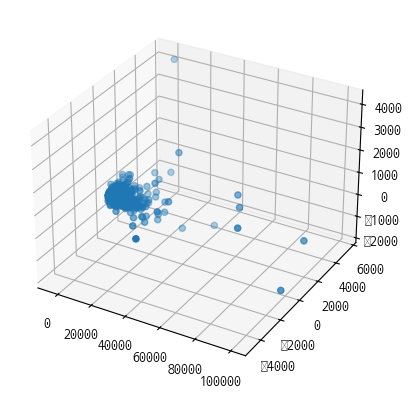

In [91]:
visual3d(x_train)

In [119]:
#KMeans를 임포트해서 5개 군집으로 나눠보기

from sklearn.cluster import KMeans

km_5 = KMeans(n_clusters=5)

km_5.fit(x_train)

km_5_pred = km_5.predict(x_train)

In [121]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x_train, km_5_pred)
print(f'k-means의 실루엣 계수는 {score}입니다')

k-means의 실루엣 계수는 0.6677299674801983입니다


In [122]:
#모듈화 처리하는 방법
def sc_score(df_,pred_):
    return silhouette_score(df_,pred_)

sc = sc_score(x_train, km_5_pred)
print(f'5개 군집 실루엣 계수: {sc}')

5개 군집 실루엣 계수: 0.6677299674801983


In [123]:
#엘보

In [127]:
#엘보 함수화
#**변수가 뭐들어가는지 꼭 짚고 넘어가주세요ㅠㅜ**
#입력: 데이터프레임
#출력: 엘보우 그래프
def create_elbow (df_,last):
    #군집 간 거리 저장할 빈 리스트
    iner = []
    for k in range(2,last+1):
        km = KMeans(n_clusters = k)
        km.fit(df_)
        iner.append(km.inertia_)

    fig, ax = plt.subplots()
    ax.plot (range(2, last+1), iner)
    plt.title(f'k가 2에서 {last}개까지의 엘보우 그래프 변화')
    plt.show()

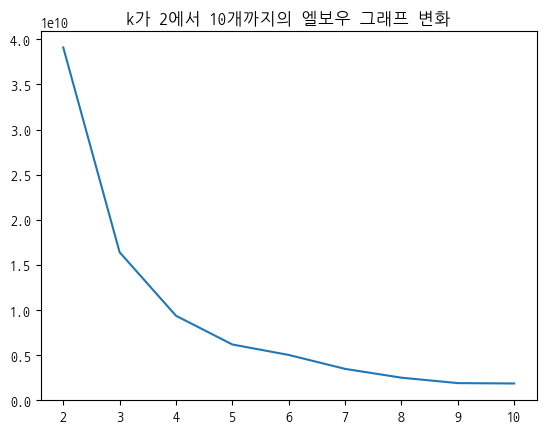

In [132]:
create_elbow(x_train, 10)

In [141]:
#KMeans를 입력한 매개변수 K에 따라 x_train 훈련, 평가하는 함수 만들기

def train(df_,k):
    #1. KMeans 객체 생성 (n_clusters =k)
    km_k = KMeans(n_clusters=k)
    #2. 훈련
    km_k.fit(df_)
    km_k_pred = km_k.predict(df_)

    #3. 실루엣 계수 평가
    sc = silhouette_score(df_,km_k_pred)
    print(f'{k}개 군집의 평가점수: {sc:.4f}')

In [144]:
for i in range(2,15):
    train(x_train, i)

2개 군집의 평가점수: 0.7820
3개 군집의 평가점수: 0.7071
4개 군집의 평가점수: 0.6715
5개 군집의 평가점수: 0.6101
6개 군집의 평가점수: 0.6102
7개 군집의 평가점수: 0.5626
8개 군집의 평가점수: 0.5770
9개 군집의 평가점수: 0.5445
10개 군집의 평가점수: 0.5389
11개 군집의 평가점수: 0.5113
12개 군집의 평가점수: 0.4890
13개 군집의 평가점수: 0.4864
14개 군집의 평가점수: 0.4634


# 새로운 알고리즘 찾는 방법

- '책'으로 나온 것들, 오래됨
- machine learning algorithms trending
- papaerswithcode
- github: explore
- ml(clustering) algorithms github

-agglomerativeClustering

In [145]:
#계층적 클러스터링

from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters =3, linkage = 'ward')

agg_pred = agg.fit_predict(x_train)
agg_sc = silhouette_score(x_train, agg_pred)
print(f'계층적 클러스터링 함수: {agg_sc}')

계층적 클러스터링 함수: 0.65325015726662


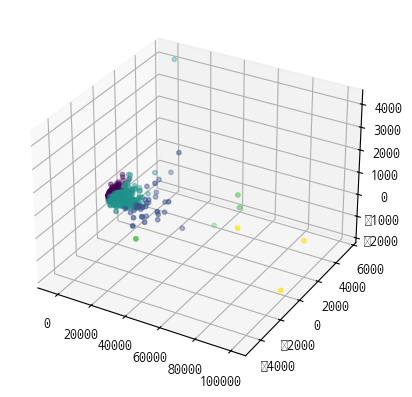

In [149]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x_train)

#scatter 플롯을 그리되, 예측된 결과를 색으로 표시

fig, ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.scatter( x_pca[:, 0],
            x_pca[:, 1],
            x_pca[:, 2],
            c = km_5_pred,
            cmap = 'viridis',
            s = 10)
plt.show()

# pip 패키지 설치 알고리즘


In [150]:
#파이썬 패키지에서 알고리즘 다운로드
!pip install kmodes

In [152]:
tdf_features

,고객ID,성별,고객지역,가입기간,제품카테고리,쿠폰상태,최근거래일,빈도수,순매출액,총할인액,총지출액,총구매수량,쿠폰사용수량,최근성,쿠폰사용비율,평균구매금액
0,USER_0000,여,New York,31,Apparel,Used,2019-09-15,1,30.99,9.297,171.693,3,3.0,107,1.000000,171.693000
1,USER_0001,남,New York,20,Office,Clicked,2019-11-02,31,13834.90,2392.863,12107.177,342,63.0,59,0.184211,390.554097
2,USER_0002,남,California,39,Drinkware,Used,2019-10-19,8,1442.12,295.721,1343.549,209,159.0,73,0.760766,167.943625
3,USER_0003,남,California,25,Nest-USA,Not Used,2019-12-14,11,1360.07,306.135,1181.815,21,7.0,17,0.333333,107.437727
4,USER_0004,여,Chicago,31,Apparel,Used,2019-09-15,13,1442.47,336.135,1743.825,56,20.0,107,0.357143,134.140385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1463,USER_1463,여,California,5,Notebooks & Journals,Clicked,2019-04-05,3,544.34,51.636,771.034,46,10.0,270,0.217391,257.011333
1464,USER_1464,남,New York,43,Office,Clicked,2019-10-05,19,2363.05,555.553,2439.917,141,60.0,87,0.425532,128.416684
1465,USER_1465,남,Chicago,25,Apparel,Not Used,2019-06-20,2,101.56,11.495,141.565,10,5.0,194,0.500000,70.782500
1466,USER_1466,여,Chicago,47,Nest-USA,Not Used,2019-10-23,1,298.00,0.000,304.000,2,NaN,69,0.000000,304.000000


In [156]:
#범주형 데이터(인코딩 필요한 것) -> 군집화

#해당 알고리즘의 좋은 점: 노 인코딩 니디드
from kmodes.kprototypes import KPrototypes
kp = KPrototypes(n_clusters = 3, init ='Cao')
tdf_features.fillna(0,inplace =True)
kp_pred = kp.fit_predict(tdf_features.to_numpy(),categorical = [0,1,2,4,5,6])

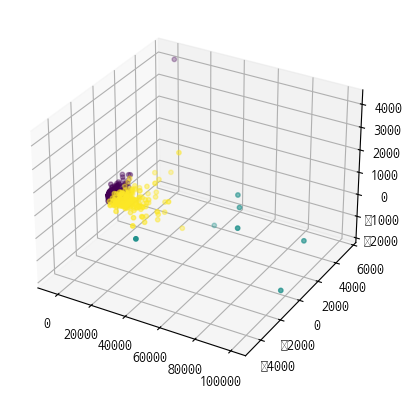

In [157]:
pca = PCA(n_components=3)
x_pca = pca.fit_transform(tdf_features.iloc[:, [3,7,8,9,10,11,12,13,14,15]])

#scatter 플롯을 그리되, 예측된 결과를 색으로 표시

fig, ax = plt.subplots(subplot_kw = {'projection':'3d'})
ax.scatter( x_pca[:, 0],
            x_pca[:, 1],
            x_pca[:, 2],
            c = kp_pred,
            cmap = 'viridis',
            s = 10)
plt.show()